# Getting Started with CRESSignalStructure

**CRES** (Cyclotron Radiation Emission Spectroscopy) is a technique for measuring the kinetic energy of electrons. When an electron is trapped in a magnetic field, it spirals along the field lines and emits cyclotron radiation at a frequency that depends on its energy. By detecting this radiation, we can infer the electron's energy with high precision.

This notebook walks through the two main signal generation pipelines in `CRESSignalStructure`:

1. **Waveguide pipeline** (Section A) — Uses an analytical trap model and a circular waveguide to compute the power spectrum, then synthesises a time-domain signal. Numerical traps can also be subbed in in this pipeline.
2. **Antenna pipeline** (Section B) — Generates a full electron trajectory in a realistic magnetic field, then computes the signal received by an antenna using Lienard-Wiechert electric fields. More physically detailed.

---
## Section A: Waveguide Pipeline

In this approach we model the electron trap analytically, calculate the CRES power spectrum in a circular waveguide, and then generate a downmixed time-domain signal.

The pipeline is:
```
Electron + HarmonicTrap + CircularWaveguide
    -> SpectrumCalculator
    -> SignalGenerator
    -> (time, complex IQ signal)
```

### A1. Define the physics

We need four objects:
- An **Electron** with a kinetic energy and pitch angle (the angle between the velocity and the magnetic field). Electrons with pitch angles near 90 degrees are moving almost entirely perpendicular to the field, which means they are deeply trapped and emit strong cyclotron radiation.
- A **HarmonicTrap** describing the magnetic field profile $B(z) = B_0(1 + z^2/L_0^2)$.
- A **CircularWaveguide** for the TE11 mode that couples to the electron's radiation.
- A **SpectrumCalculator** that combines these to compute peak frequencies and amplitudes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CRESSignalStructure import (
    Electron, HarmonicTrap, CircularWaveguide,
    SpectrumCalculator, SignalGenerator
)

# 18.6 keV electron at 89.8 degrees pitch angle
electron = Electron(ke=18.6e3, startPos=np.zeros(3),
                    pitchAngle=89.8 * np.pi / 180)

# Harmonic magnetic trap: 1 T background field, 20 cm scale length
trap = HarmonicTrap(B0=1.0, L0=0.2)

# Circular waveguide with 5 mm radius (TE11 mode)
waveguide = CircularWaveguide(radius=5e-3)

# Combine into a spectrum calculator
spectrum = SpectrumCalculator(trap, waveguide, electron)

### A2. Inspect the spectrum

The electron's axial bouncing motion in the trap modulates the cyclotron radiation, creating sidebands spaced by the axial frequency $f_a$ around the central cyclotron frequency $f_0$. The power in each sideband depends on the pitch angle and trap geometry.

In [2]:
# Central cyclotron frequency and power
f0 = spectrum.get_peak_frequency(0)
P0 = spectrum.get_peak_power(0)

# Axial (bounce) frequency
fa = trap.calc_omega_axial(electron.get_speed(),
                           electron.get_pitch_angle()) / (2 * np.pi)

print(f"Cyclotron frequency:  {f0 / 1e9:.4f} GHz")
print(f"Axial frequency:     {fa / 1e6:.2f} MHz  (sideband spacing)")
print(f"Fundamental power:   {P0 * 1e15:.2f} fW")

Cyclotron frequency:  27.0095 GHz
Axial frequency:     62.67 MHz  (sideband spacing)
Fundamental power:   0.50 fW


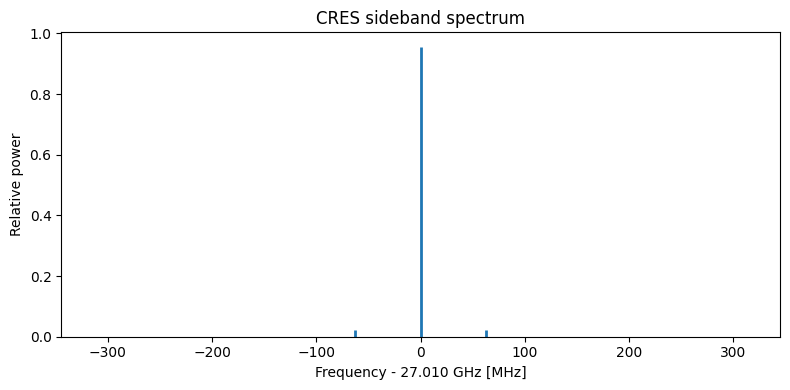

In [3]:
# Plot the sideband spectrum
orders = np.arange(-5, 6)
frequencies = spectrum.get_peak_frequency(orders)
relative_powers = np.abs(spectrum.get_peak_amp(orders))**2

fig, ax = plt.subplots(figsize=(8, 4))
ax.vlines((frequencies - f0) / 1e6, 0, relative_powers, linewidth=2)
ax.set_xlabel(f"Frequency - {f0/1e9:.3f} GHz [MHz]")
ax.set_ylabel("Relative power")
ax.set_title("CRES sideband spectrum")
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

### A3. Choose digitizer settings

Before generating a time-domain signal, we need to set up the simulated receiver:
- **Sample rate** — the ADC digitisation rate. We use 1 GHz.
- **LO frequency** — the local oscillator used to downmix the ~27 GHz cyclotron signal to baseband. We choose $f_{\text{LO}} = f_0 - f_s/4$ so that the intermediate frequency lands at roughly $f_s/4 \approx 250$ MHz, safely below the Nyquist limit of $f_s/2 = 500$ MHz.
- **Acquisition time** — how long we record for.

In [4]:
SAMPLE_RATE = 1e9        # 1 GHz ADC
LO_FREQ = f0 - 200e6     # ~200 MHz IF
ACQ_TIME = 40e-6         # 40 microseconds

print(f"LO frequency:        {LO_FREQ / 1e9:.4f} GHz")
print(f"Expected IF:         {(f0 - LO_FREQ) / 1e6:.1f} MHz")
print(f"Nyquist frequency:   {SAMPLE_RATE / 2 / 1e6:.0f} MHz")

LO frequency:        26.8095 GHz
Expected IF:         200.0 MHz
Nyquist frequency:   500 MHz


### A4. Generate and plot the signal

The `SignalGenerator` creates a complex (IQ) time-domain signal by summing sideband contributions up to `max_order`, applying the LO downmix, low-pass filtering, and decimating to the ADC sample rate. The signal includes a frequency chirp from radiation energy loss.

In [5]:
sig_gen = SignalGenerator(spectrum, SAMPLE_RATE, LO_FREQ, ACQ_TIME)
t_wg, signal_wg = sig_gen.generate_signal(max_order=5)

print(f"Generated {len(signal_wg)} samples over {t_wg[-1]*1e6:.1f} us")

Generated 40000 samples over 40.0 us


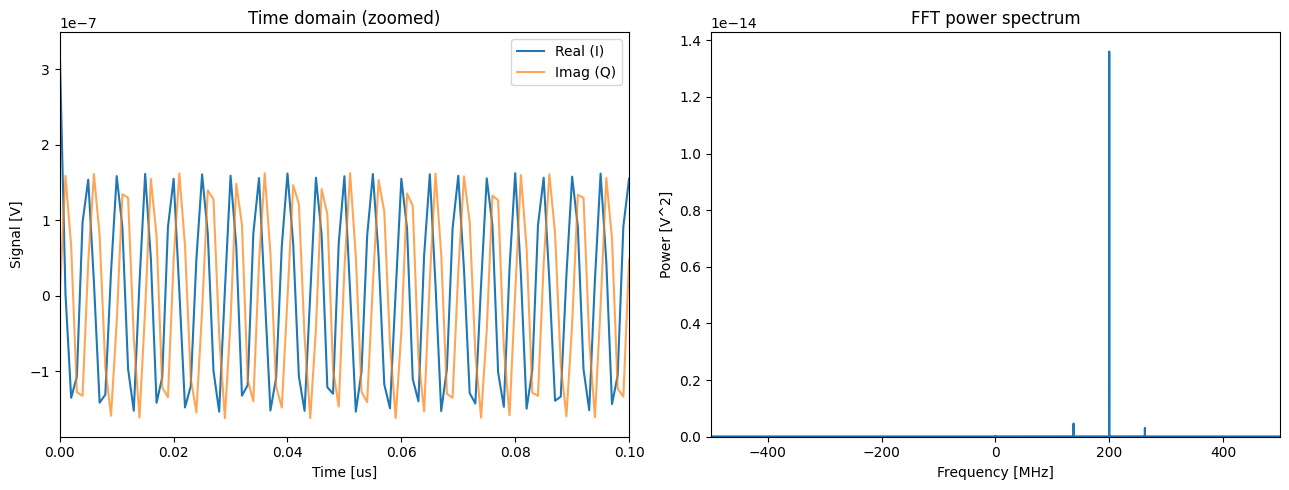

In [6]:
import scipy.fft

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Time domain (zoom into first 0.1 us to see oscillations)
ax[0].plot(t_wg * 1e6, np.real(signal_wg), label="Real (I)")
ax[0].plot(t_wg * 1e6, np.imag(signal_wg), label="Imag (Q)", alpha=0.7)
ax[0].set_xlabel("Time [us]")
ax[0].set_ylabel("Signal [V]")
ax[0].set_xlim(0, 0.1)
ax[0].set_title("Time domain (zoomed)")
ax[0].legend()

# FFT power spectrum
fft_vals = scipy.fft.fft(signal_wg, norm='forward')
fft_freqs = scipy.fft.fftfreq(len(signal_wg), 1 / SAMPLE_RATE)
ax[1].plot(fft_freqs / 1e6, np.abs(fft_vals)**2)
ax[1].set_xlabel("Frequency [MHz]")
ax[1].set_ylabel("Power [V^2]")
ax[1].set_xlim(-500, 500)
ax[1].set_ylim(0, None)
ax[1].set_title("FFT power spectrum")

plt.tight_layout()
plt.show()

---
## Section B: Antenna Pipeline

In this approach we compute a full electron trajectory in a magnetic field generated by current loops, then calculate the signal at an antenna using the Lienard-Wiechert electric fields. This is more physically realistic but slower than the waveguide pipeline.

The pipeline is:
```
Electron + HarmonicField
    -> TrajectoryGenerator -> Trajectory
    + IsotropicAntenna + ReceiverChain
    -> AntennaSignalGenerator
    -> (time, complex IQ signal)
```

### B1. Create the magnetic field

Unlike `HarmonicTrap` (which uses an analytical formula), `HarmonicField` computes the field from an actual current loop using the Biot-Savart law. The `TrajectoryGenerator` requires a `BaseField` subclass, so we must use `HarmonicField` here.

The coil current needed for a given trap depth $\Delta B$ with coil radius $R$ is approximately $I = 2 \Delta B \cdot R / \mu_0$.

In [7]:
import scipy.constants as sc
from CRESSignalStructure import (
    HarmonicField, IsotropicAntenna,
    TrajectoryGenerator, ReceiverChain, AntennaSignalGenerator
)

TRAP_DEPTH = 4e-3    # 4 mT
R_COIL = 1.25e-2     # 1.25 cm
I_COIL = 2 * TRAP_DEPTH * R_COIL / sc.mu_0

field = HarmonicField(radius=R_COIL, current=I_COIL, background=1.0)
print(f"Coil current: {I_COIL:.1f} A")

Coil current: 79.6 A


### B2. Create the electron (off-axis)

We place the electron slightly off-axis (1 mm from the centre). This is important because the magnetic field gradient causes a slow azimuthal **grad-B drift** of the electron's guiding centre, which affects the signal modulation. On-axis electrons don't experience this drift.

In [8]:
electron_ant = Electron(
    ke=18.6e3,
    startPos=np.array([1e-3, 0, 0]),  # 1 mm off-axis
    pitchAngle=89.5 * np.pi / 180
)

### B3. Generate the trajectory

The `TrajectoryGenerator` integrates the relativistic equations of motion in the magnetic field. The trajectory sample rate must exceed `adc_rate * oversampling_factor` (the `AntennaSignalGenerator` oversamples by 5x by default, so with a 1 GHz ADC we need > 5 GHz). We use 10 GHz to be safe.

In [9]:
traj_gen = TrajectoryGenerator(field, electron_ant)
trajectory = traj_gen.generate(sample_rate=10e9, t_max=40e-6)

print(f"Trajectory: {trajectory.get_n_points()} points "
      f"over {trajectory.get_duration() * 1e6:.1f} us")

Trajectory: 400001 points over 40.0 us


### B4. Set up the antenna and receiver

We use an **isotropic antenna** (equal sensitivity in all directions) placed 7 cm from the trap centre. The **receiver chain** handles downmixing with a 26 GHz local oscillator and digitisation at 1 GHz.

In [10]:
antenna = IsotropicAntenna(position=np.array([0.05, 0, 0]))
receiver = ReceiverChain(sample_rate=1e9, lo_frequency=26.8e9)

### B5. Generate and plot the signal

The `AntennaSignalGenerator` computes the Lienard-Wiechert electric field at the antenna for each trajectory point, applies the antenna response and receiver chain (downmixing, filtering, decimation), and returns the digitised IQ signal.

In [11]:
ant_sig_gen = AntennaSignalGenerator(trajectory, antenna, receiver)
t_ant, signal_ant = ant_sig_gen.generate_signal()

print(f"Generated {len(signal_ant)} samples over {t_ant[-1]*1e6:.1f} us")

Generated 40000 samples over 40.0 us


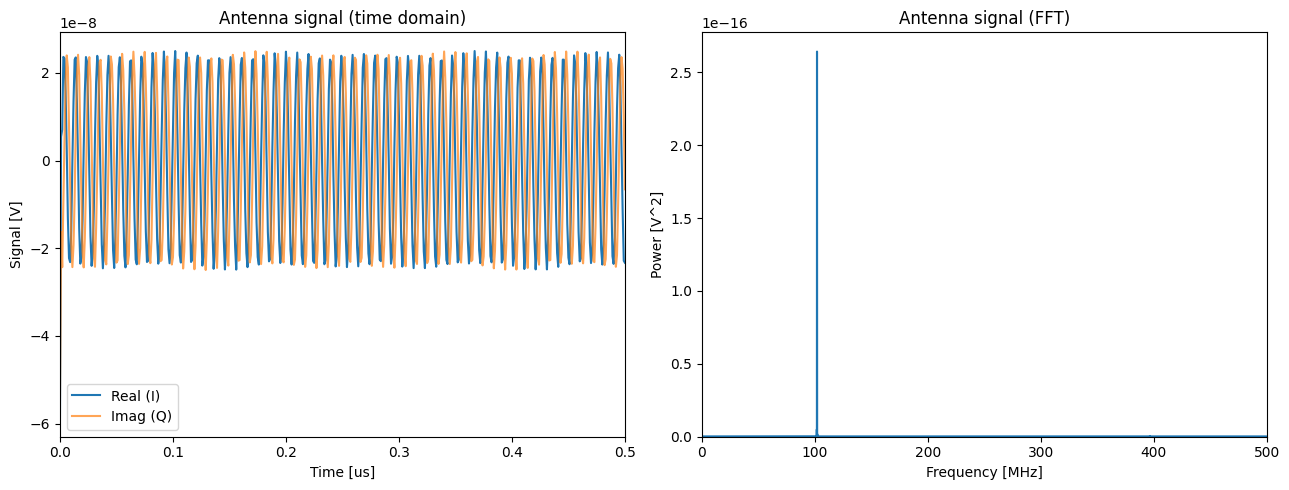

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Time domain
ax[0].plot(t_ant * 1e6, np.real(signal_ant), label="Real (I)")
ax[0].plot(t_ant * 1e6, np.imag(signal_ant), label="Imag (Q)", alpha=0.7)
ax[0].set_xlabel("Time [us]")
ax[0].set_ylabel("Signal [V]")
ax[0].set_xlim(0, 0.5)
ax[0].set_title("Antenna signal (time domain)")
ax[0].legend()

# FFT power spectrum
ANT_SAMPLE_RATE = 1e9
fft_ant = scipy.fft.fft(signal_ant, norm='forward')
fft_freqs_ant = scipy.fft.fftfreq(len(signal_ant), 1 / ANT_SAMPLE_RATE)
ax[1].plot(fft_freqs_ant / 1e6, np.abs(fft_ant)**2)
ax[1].set_xlabel("Frequency [MHz]")
ax[1].set_ylabel("Power [V^2]")
ax[1].set_xlim(0, 500)
ax[1].set_ylim(0, None)
ax[1].set_title("Antenna signal (FFT)")

plt.tight_layout()
plt.show()

---
## Summary

| | Waveguide pipeline | Antenna pipeline |
|---|---|---|
| **Speed** | Fast (analytical) | Slower (trajectory integration + field calculation) |
| **Trap model** | `HarmonicTrap` / `BathtubTrap` (analytical) or `HarmonicField` / `BathtubField` (numerical) | `HarmonicField` / `BathtubField` (numerical only) |
| **Detection** | Circular waveguide TE11 mode | Any antenna model (isotropic, dipole, etc.) |
| **Best for** | Parameter scans, quick estimates | Realistic signal simulation with antenna geometry |

For deeper dives, see the other example notebooks:
- `HarmonicComparison.ipynb` — Comparing analytical traps to numerical fields
- `RealisticFields.ipynb` — Working with bathtub fields from current loops
- `SignalGenExample.ipynb` — Signal generation with noise injection